In [1]:
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from shapely import geometry
from captum.attr import IntegratedGradients

spec = importlib.util.spec_from_file_location("helpers", "13-helpers.py")
helpers = importlib.util.module_from_spec(spec)
spec.loader.exec_module(helpers)

In [2]:
geoms = helpers.get_all_geoms("../data/karnataka_predictions_polygons_validated_2020.geojson")

i = 4
side = np.sqrt(geometry.shape(geoms[i]).area)
buffer = max(side * 1.5, 0.001)
image = helpers.get_sentinel_image(geoms[i], buffer=buffer)

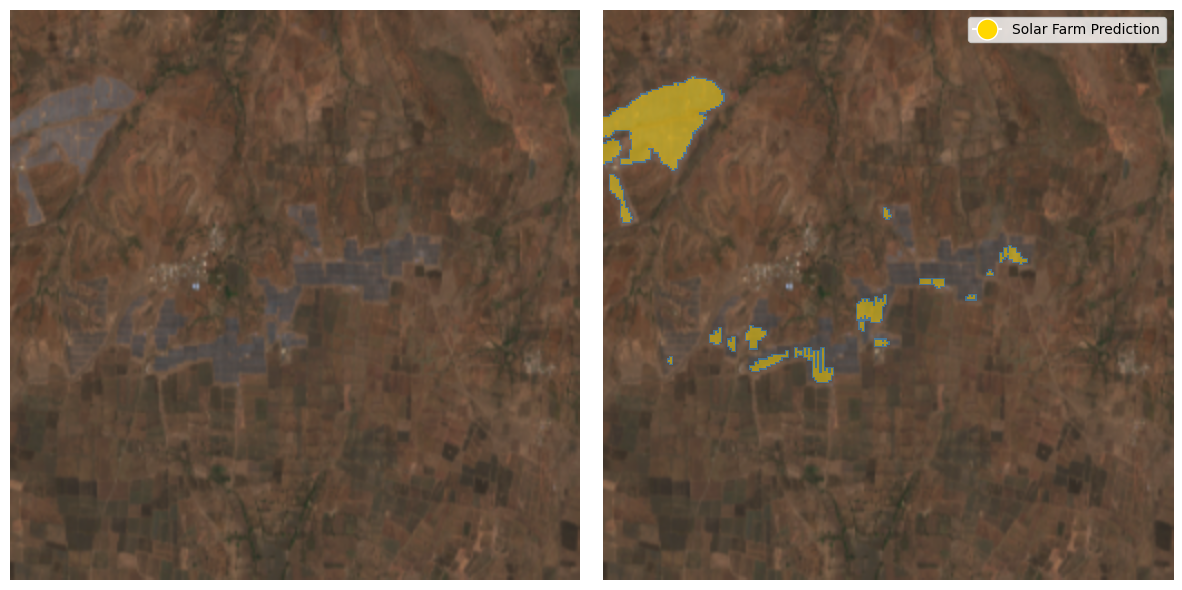

In [3]:
model = helpers.load_model("../data/solar/solar_checkpoint.pth.tar")
img, x_tensor = helpers.preprocess(image)
prediction = helpers.predict_mask(model, x_tensor)

rgb = helpers.scale(img[:, :, [3, 2, 1]], 0, 3000)
helpers.plot_sample_prediction(rgb, prediction)

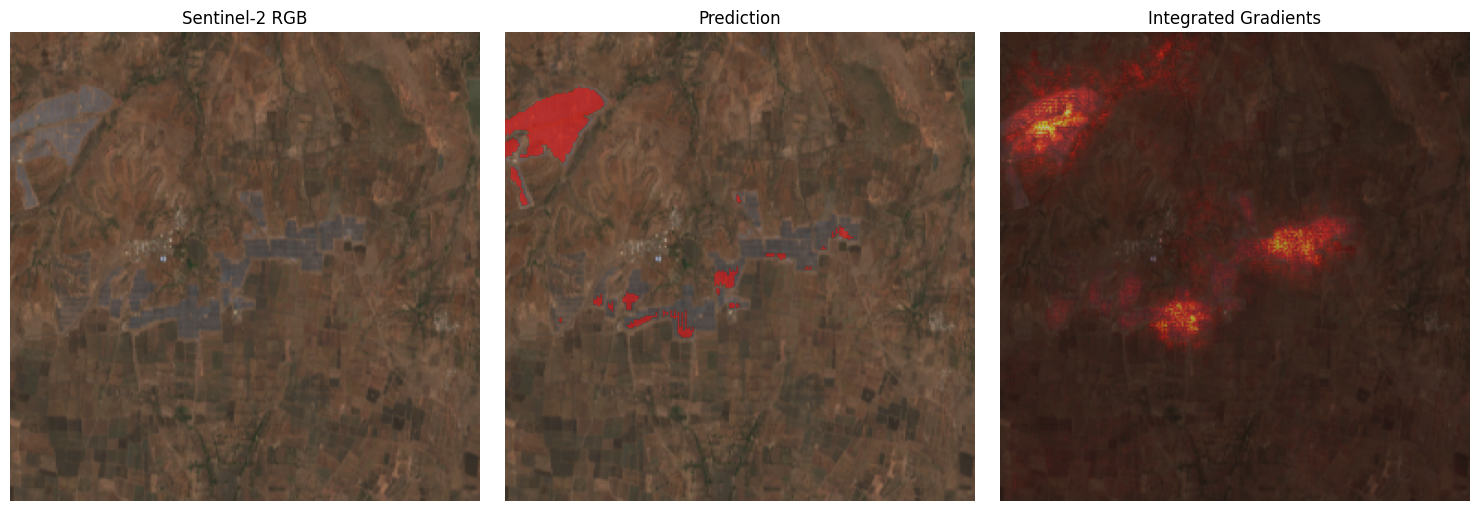

In [4]:
# we sum the "solar" class logic across pixels, so we get a single scalar on
# which to run the integrated gradients
def forward_solar_score(inp):
    return model(inp)[:, 1].sum(dim=(1, 2))

x_tensor.requires_grad_()
ig = IntegratedGradients(forward_solar_score)
attributions = ig.attribute(
    x_tensor,
    n_steps=32
)

attr = attributions.squeeze(0).detach().cpu().numpy()
heatmap = np.abs(attr).sum(axis=0)
heatmap = heatmap / heatmap.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb); axes[0].set_title("Sentinel-2 RGB"); axes[0].axis("off")
axes[1].imshow(rgb)
axes[1].imshow(np.ma.masked_where(prediction == 0, prediction), alpha=0.5, cmap="autumn")
axes[1].set_title("Prediction"); axes[1].axis("off")
axes[2].imshow(rgb)
axes[2].imshow(heatmap, cmap="hot", alpha=0.5)
axes[2].set_title("Integrated Gradients"); axes[2].axis("off")
plt.tight_layout()